
# Fitting NuSTAR Spectra: Duncan *et al.* 2021 comparison

This spectrum corresponds to the may1618 microflare in [Duncan2021]_.

An example of fitting multiple spectra simultaneously with 2 models where each model is allowed to vary at different times

We also allow the gain slope response parameter to vary.


In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
from numpy.exceptions import VisibleDeprecationWarning
from parfive import Downloader

from sunkit_spex.legacy.fitting.fitter import Fitter

warnings.filterwarnings("ignore", category=RuntimeWarning)
try:
    warnings.filterwarnings("ignore", category=VisibleDeprecationWarning)
except AttributeError:
    warnings.filterwarnings("ignore", category=np.exceptions.VisibleDeprecationWarning)

Set up some plotting numbers



In [2]:
spec_single_plot_size = (8, 10)
spec_plot_size = (25, 10)
spec_font_size = 18
default_font_size = 10
x_limits, y_limits = [1.6, 8.5], [1e-1, 1e3]

# set up plotting info stuff

dunc_xlims, dunc_ylims = [2.5, 11], [1e0, 4e4]

Download the example data



In [ ]:
# dl = Downloader()

# base_url = "https://homepages.dias.ie/smaloney/sunkit-spex/nustar/Duncan2021/"
# file_names = [
#     "nu80410201001A06_1618_p_chu2_N_sr.pha",
#     "nu80410201001A06_1618_p_chu2_N_sr.arf",
#     "nu80410201001A06_1618_p_chu2_N_sr.rmf",
#     "nu80410201001B06_1618_p_chu2_N_sr.pha",
#     "nu80410201001B06_1618_p_chu2_N_sr.arf",
#     "nu80410201001B06_1618_p_chu2_N_sr.rmf",
# ]

# for fname in file_names:
#     dl.enqueue_file(base_url + fname, path="data/")
# files = dl.download()

Files Downloaded:   0%|          | 0/6 [00:00<?, ?file/s]

nu80410201001B06_1618_p_chu2_N_sr.pha:   0%|          | 0.00/153k [00:00<?, ?B/s]

nu80410201001A06_1618_p_chu2_N_sr.rmf:   0%|          | 0.00/30.5M [00:00<?, ?B/s]

nu80410201001B06_1618_p_chu2_N_sr.arf:   0%|          | 0.00/63.4k [00:00<?, ?B/s]

nu80410201001A06_1618_p_chu2_N_sr.pha:   0%|          | 0.00/153k [00:00<?, ?B/s]

nu80410201001A06_1618_p_chu2_N_sr.arf:   0%|          | 0.00/63.4k [00:00<?, ?B/s]

nu80410201001B06_1618_p_chu2_N_sr.rmf:   0%|          | 0.00/27.0M [00:00<?, ?B/s]

First, load in your data files, here we load in 2 spectra



In [4]:
_dir = "data/"
spec = Fitter(pha_file=[_dir + "nu80410201001A06_1618_p_chu2_N_sr.pha", _dir + "nu80410201001B06_1618_p_chu2_N_sr.pha"])

Define model, here we go for 2 isothermal models



In [5]:
spec.model = "C*(f_vth + f_vth)"

Check the parameter table



In [6]:
print(spec.params)

                          Status  Value       Bounds       Error
T1_spectrum1                free    1.0  (0.0, None)  (0.0, 0.0)
EM1_spectrum1               free    1.0  (0.0, None)  (0.0, 0.0)
T2_spectrum1                free    1.0  (0.0, None)  (0.0, 0.0)
EM2_spectrum1               free    1.0  (0.0, None)  (0.0, 0.0)
C_spectrum1                 free    1.0  (0.0, None)  (0.0, 0.0)
T1_spectrum2    tie_T1_spectrum1    1.0  (0.0, None)  (0.0, 0.0)
EM1_spectrum2  tie_EM1_spectrum1    1.0  (0.0, None)  (0.0, 0.0)
T2_spectrum2    tie_T2_spectrum1    1.0  (0.0, None)  (0.0, 0.0)
EM2_spectrum2  tie_EM2_spectrum1    1.0  (0.0, None)  (0.0, 0.0)
C_spectrum2      tie_C_spectrum1    1.0  (0.0, None)  (0.0, 0.0)


freeze the ones we don't want to vary



In [7]:
spec.params["C_spectrum1"] = {"Status": "frozen"}

Set initial values



In [8]:
spec.params["T1_spectrum1"] = {"Value": 4.1, "Bounds": (2.5, 6)}
spec.params["EM1_spectrum1"] = {"Value": 14, "Bounds": (1e0, 1e2)}
spec.params["T2_spectrum1"] = {"Value": 10, "Bounds": (5, 15)}
spec.params["EM2_spectrum1"] = {"Value": 0.46, "Bounds": (1e-4, 10)}
spec.params["C_spectrum2"] = {"Status": "free", "Bounds": (0.5, 2)}

Fit lower energy range with the first thermal model first



In [9]:
spec.params["T2_spectrum1"] = "frozen"
spec.params["EM2_spectrum1"] = "frozen"
spec.energy_fitting_range = [2.5, 4]

spec.fit(tol=1e-6)
print(spec.params)
print(spec.rParams)

                          Status      Value        Bounds  \
T1_spectrum1                free   5.563455      (2.5, 6)   
EM1_spectrum1               free   2.724285  (1.0, 100.0)   
T2_spectrum1              frozen  10.000000       (5, 15)   
EM2_spectrum1             frozen   0.460000  (0.0001, 10)   
C_spectrum1               frozen   1.000000   (0.0, None)   
T1_spectrum2    tie_T1_spectrum1   5.563455   (0.0, None)   
EM1_spectrum2  tie_EM1_spectrum1   2.724285   (0.0, None)   
T2_spectrum2    tie_T2_spectrum1  10.000000   (0.0, None)   
EM2_spectrum2  tie_EM2_spectrum1   0.460000   (0.0, None)   
C_spectrum2                 free   0.950149      (0.5, 2)   

                                                      Error  
T1_spectrum1     (0.05064320379181307, 0.05064320379181307)  
EM1_spectrum1    (0.11786782714932843, 0.11786782714932843)  
T2_spectrum1                                     (0.0, 0.0)  
EM2_spectrum1                                    (0.0, 0.0)  
C_spectrum1       

Now fit higher energy range with the second thermal model



In [10]:
spec.params["T1_spectrum1"] = "frozen"
spec.params["EM1_spectrum1"] = "frozen"
spec.params["C_spectrum2"] = "frozen"
spec.params["T2_spectrum1"] = "free"
spec.params["EM2_spectrum1"] = "free"

Need the gain slope to vary too for this microflare but only needed for the 6.7 keV line



In [11]:
print(spec.rParams)
spec.rParams["gain_slope_spectrum1"] = "free"
spec.rParams["gain_slope_spectrum2"] = spec.rParams["gain_slope_spectrum1"]

spec.energy_fitting_range = [4, 10.8]

spec.fit(tol=1e-6)
print(spec.params)
print(spec.rParams)

                       Status  Value       Bounds       Error
gain_slope_spectrum1   frozen    1.0   (0.8, 1.2)  (0.0, 0.0)
gain_offset_spectrum1  frozen    0.0  (-0.1, 0.1)  (0.0, 0.0)
gain_slope_spectrum2   frozen    1.0   (0.8, 1.2)  (0.0, 0.0)
gain_offset_spectrum2  frozen    0.0  (-0.1, 0.1)  (0.0, 0.0)
                          Status      Value        Bounds  \
T1_spectrum1              frozen   5.563455      (2.5, 6)   
EM1_spectrum1             frozen   2.724285  (1.0, 100.0)   
T2_spectrum1                free  10.494323       (5, 15)   
EM2_spectrum1               free   0.391337  (0.0001, 10)   
C_spectrum1               frozen   1.000000   (0.0, None)   
T1_spectrum2    tie_T1_spectrum1   5.563455   (0.0, None)   
EM1_spectrum2  tie_EM1_spectrum1   2.724285   (0.0, None)   
T2_spectrum2    tie_T2_spectrum1  10.494323   (0.0, None)   
EM2_spectrum2  tie_EM2_spectrum1   0.391337   (0.0, None)   
C_spectrum2               frozen   0.950149      (0.5, 2)   

                  

Now free everything over full range



In [12]:
spec.params["T1_spectrum1"] = "free"
spec.params["EM1_spectrum1"] = "free"
spec.params["C_spectrum2"] = "free"

spec.energy_fitting_range = [3, 10.8]

spec.fit(tol=1e-10)
print(spec.params)
print(spec.rParams)

                          Status      Value        Bounds  \
T1_spectrum1                free   4.780847      (2.5, 6)   
EM1_spectrum1               free   7.575536  (1.0, 100.0)   
T2_spectrum1                free  10.393591       (5, 15)   
EM2_spectrum1               free   0.424575  (0.0001, 10)   
C_spectrum1               frozen   1.000000   (0.0, None)   
T1_spectrum2    tie_T1_spectrum1   4.780847   (0.0, None)   
EM1_spectrum2  tie_EM1_spectrum1   7.575536   (0.0, None)   
T2_spectrum2    tie_T2_spectrum1  10.393591   (0.0, None)   
EM2_spectrum2  tie_EM2_spectrum1   0.424575   (0.0, None)   
C_spectrum2                 free   0.969867      (0.5, 2)   

                                                      Error  
T1_spectrum1       (0.2872980298928344, 0.2872980298928344)  
EM1_spectrum1      (2.4356047501995413, 2.4356047501995413)  
T2_spectrum1     (0.09072419115507867, 0.09072419115507867)  
EM2_spectrum1    (0.02784027934513736, 0.02784027934513736)  
C_spectrum1       

Plot the result



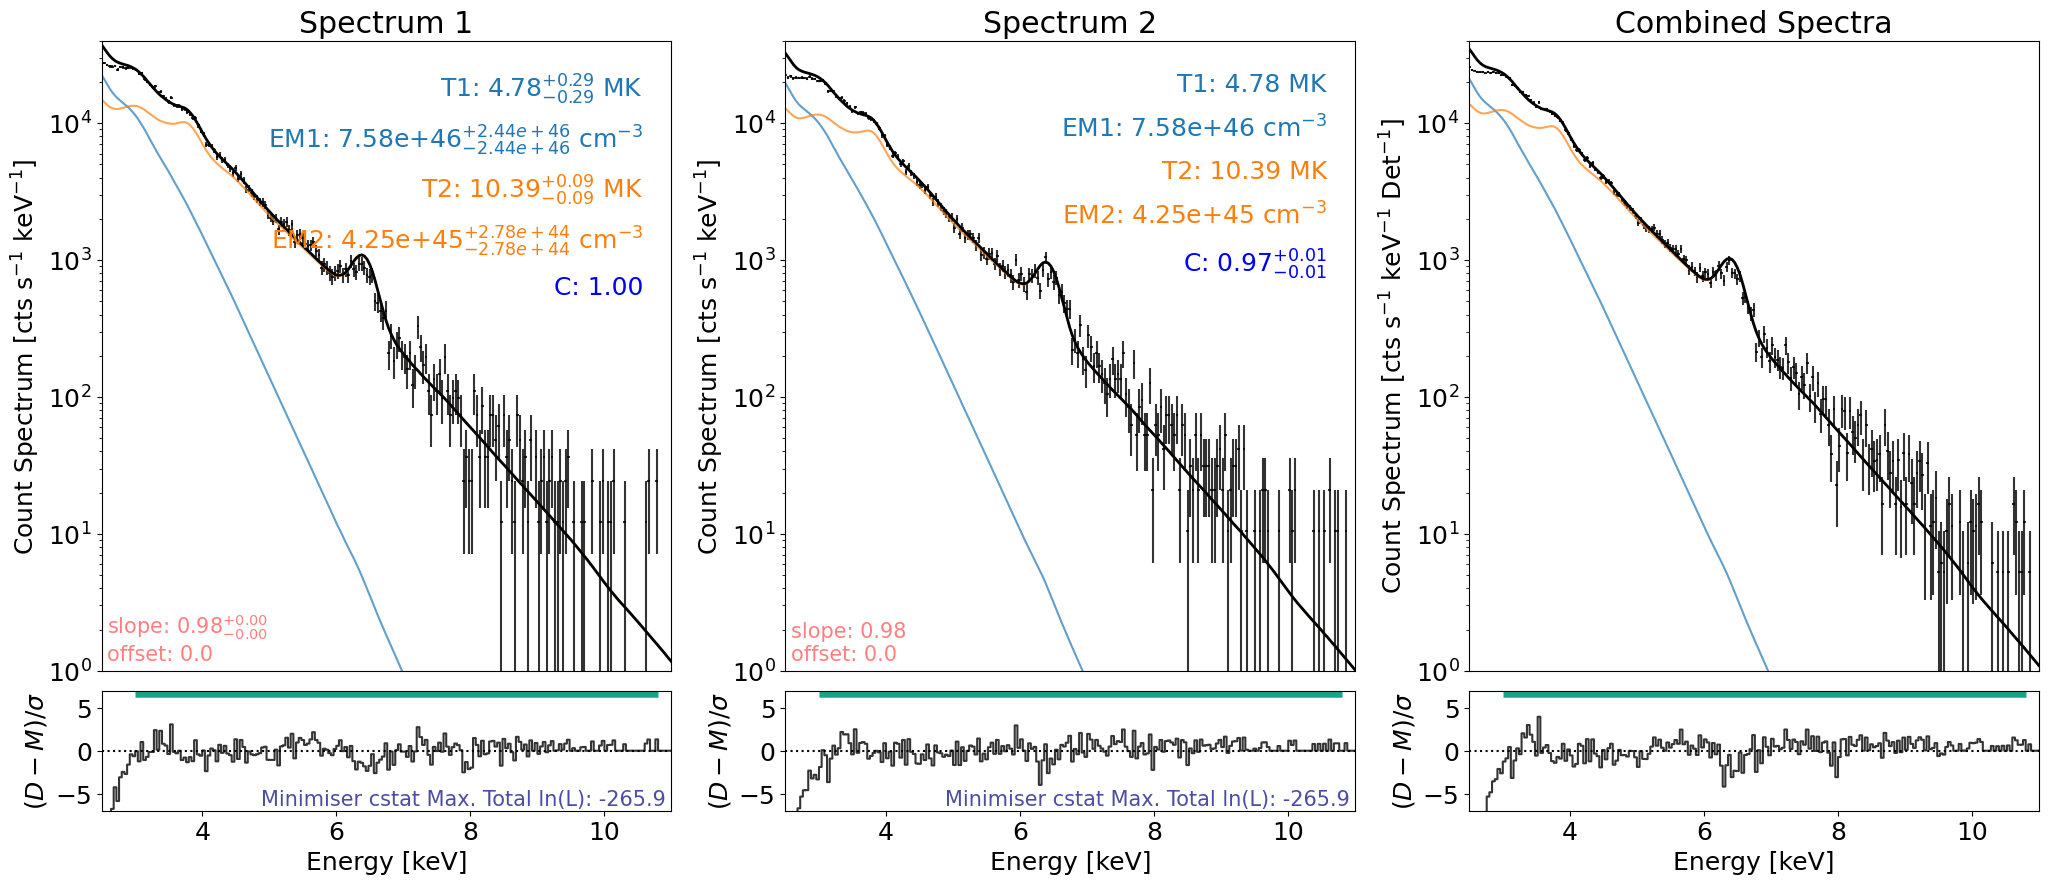

In [13]:
plt.rcParams["font.size"] = spec_font_size
plt.figure(figsize=spec_plot_size)
axes, res_axes = spec.plot()
for a in axes:
    a.set_xlim(dunc_xlims)
    a.set_ylim(dunc_ylims)
plt.show()
plt.rcParams["font.size"] = default_font_size

For the 2 thermal model fitting

| Model Parameter | XSPEC (Duncan et al. 2021) | This Work |
|---|---|---|
| Temperature 1 [MK] | $4.1^{+0.1}_{-0.1}$ | $4.8 \pm 0.3$ |
| Emission Measure 1 [$\mathrm{cm}^{-3}$] | $1.4^{+0.6}_{-0.4} \times 10^{47}$ | $(7.6 \pm 2.4) \times 10^{46}$ |
| Temperature 2 [MK] | $10.00^{+0.03}_{-0.03}$ | $10.4 \pm 0.1$ |
| Emission Measure 2 [$\mathrm{cm}^{-3}$] | $4.6^{+0.1}_{-0.2} \times 10^{45}$ | $(4.3 \pm 0.3) \times 10^{45}$ |

*Duncan et al. (2021) May 16 18 microflare:* https://iopscience.iop.org/article/10.3847/1538-4357/abca3d

For the gain parameters

| Model Parameter | XSPEC (Duncan et al. 2021) | This Work |
|---|---|---|
| Gain Slope | $0.977 \pm 0.002$ | $0.978 \pm 0.001$ |

Although these values are slightly different, it is important to note that XSPEC and sunkit-spex work from different atomic databases. We also note that for a similar isothermal fit the temperature can drop/rise if the emission measure rises/drops and so fitting not just one but two of these models allows for these to vary more. We do see that this work (for this microflare) produces higher temperatures but correspondingly lower emission measures.

